# EEG Motor Imagery Classification

This notebook explores the classification of left- vs right-hand motor imagery from EEG recordings using the PhysioNet EEG Motor Movement/Imagery dataset.

The analysis compares simple physiologically motivated band-power features with Common Spatial Patterns (CSP), using logistic regression and cross-validation for classification.

In [19]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mne.datasets import eegbci
from mne.decoding import CSP

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    cross_val_predict,
)
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)
from sklearn.pipeline import make_pipeline

mne.set_log_level("WARNING")

## 1. Dataset and single-run exploration

The PhysioNet EEG Motor Movement/Imagery dataset contains 64-channel EEG recordings sampled at 160 Hz.

This project uses Subject 1 and runs 4, 8, and 12, which correspond to imagined left- vs right-fist movement. Run 4 is first explored individually to understand the signal structure and event annotations before combining all three runs for classification.

In [20]:
subject = 1
runs = [4, 8, 12]

files = eegbci.load_data(subject, runs)

print(files)

[WindowsPath('C:/Users/diopi/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R04.edf'), WindowsPath('C:/Users/diopi/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R08.edf'), WindowsPath('C:/Users/diopi/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R12.edf')]


In [21]:
raw = mne.io.read_raw_edf(files[0], preload=True)

eegbci.standardize(raw)

montage = mne.channels.make_standard_montage("standard_1005")
raw.set_montage(montage)

print(raw)
print("Sampling frequency:", raw.info["sfreq"], "Hz")
print("Number of channels:", raw.info["nchan"])
print("Annotations:", raw.annotations)

<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.9 MiB, data loaded>
Sampling frequency: 160.0 Hz
Number of channels: 64
Annotations: <Annotations | 30 segments: T0 (15), T1 (8), T2 (7)>


In [22]:
events, event_id = mne.events_from_annotations(raw)

print(event_id)
print(events[:10])

{np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}
[[   0    0    1]
 [ 672    0    3]
 [1328    0    1]
 [2000    0    2]
 [2656    0    1]
 [3328    0    2]
 [3984    0    1]
 [4656    0    3]
 [5312    0    1]
 [5984    0    3]]


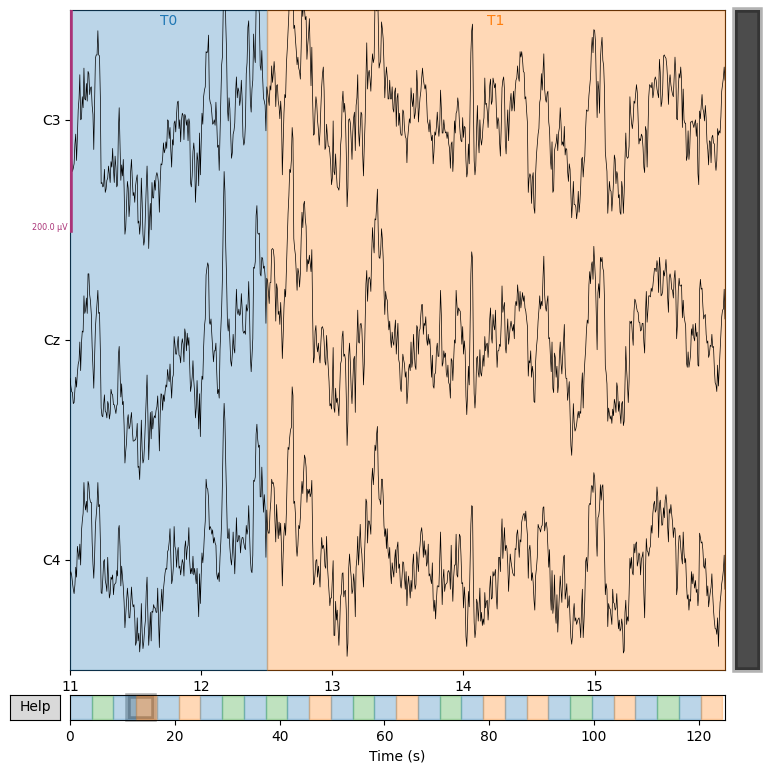

In [23]:
browser = raw.plot(
    start=11,
    duration=5,
    picks=["C3", "Cz", "C4"],
    scalings={"eeg": 100e-6}
)

The experiment alternates approximately 4-second rest and motor-imagery periods:

- `T0`: rest
- `T1`: imagined left-fist movement
- `T2`: imagined right-fist movement

The C3, Cz, and C4 electrodes are shown because they lie over sensorimotor regions relevant to hand motor imagery.  

## 2. Full three-run dataset

After exploring a single recording, runs 4, 8, and 12 are combined for the classification analysis.

Together, the three runs contain 45 motor-imagery trials:

- 23 left-hand imagery trials
- 22 right-hand imagery trials

All recordings are standardized to the same channel naming convention and assigned the same 10–05 electrode montage before concatenation.

In [24]:
raws = []

for file in files:
    run_raw = mne.io.read_raw_edf(file, preload=True)
    eegbci.standardize(run_raw)
    run_raw.set_montage(montage)
    raws.append(run_raw)

combined_raw = mne.concatenate_raws(raws)

print(combined_raw)
print(f"Duration: {combined_raw.times[-1]:.1f} s")

<RawEDF | S001R04.edf, 64 x 60000 (375.0 s), ~29.4 MiB, data loaded>
Duration: 375.0 s


In [25]:
combined_events, combined_event_id = mne.events_from_annotations(combined_raw)

combined_motor_event_id = {
    "left": combined_event_id["T1"],
    "right": combined_event_id["T2"]
}

combined_epochs = mne.Epochs(
    combined_raw,
    combined_events,
    event_id=combined_motor_event_id,
    tmin=0,
    tmax=4.0,
    baseline=None,
    preload=True
)

combined_y = combined_epochs.events[:, 2]

combined_y_binary = np.where(
    combined_y == combined_motor_event_id["left"],
    0,
    1
)

print(combined_epochs)
print("Left trials:", np.sum(combined_y_binary == 0))
print("Right trials:", np.sum(combined_y_binary == 1))

<Epochs | 45 events (all good), 0 – 4 s (baseline off), ~14.2 MiB, data loaded,
 'left': 23
 'right': 22>
Left trials: 23
Right trials: 22


Each motor-imagery period is extracted as a 4-second EEG epoch.

The binary classification labels are defined as:

- `0`: left-hand imagery
- `1`: right-hand imagery

This yields 45 trials in total, with 23 left-hand and 22 right-hand trials.

## 3. Spectral features and baseline classification

Motor imagery is associated with changes in sensorimotor rhythms, particularly in the mu (8–13 Hz) and beta (13–30 Hz) bands.

As a simple baseline, power spectral density (PSD) is computed at the C3 and C4 electrodes. Band power is then used to construct physiologically motivated features for logistic-regression classification.

All models are evaluated using stratified 5-fold cross-validation.

In [26]:
combined_psd = combined_epochs.compute_psd(
    fmin=1,
    fmax=40,
    picks=["C3", "C4"]
)

psd_data, freqs = combined_psd.get_data(return_freqs=True)

# Mu-band power: 8–13 Hz
mu_mask = (freqs >= 8) & (freqs <= 13)

mu_power = np.trapezoid(
    psd_data[:, :, mu_mask],
    freqs[mu_mask],
    axis=2
)

mu_power_db = 10 * np.log10(mu_power * 1e12)

# Beta-band power: 13–30 Hz
beta_mask = (freqs >= 13) & (freqs <= 30)

beta_power = np.trapezoid(
    psd_data[:, :, beta_mask],
    freqs[beta_mask],
    axis=2
)

beta_power_db = 10 * np.log10(beta_power * 1e12)

print("Mu features:", mu_power_db.shape)
print("Beta features:", beta_power_db.shape)

Mu features: (45, 2)
Beta features: (45, 2)


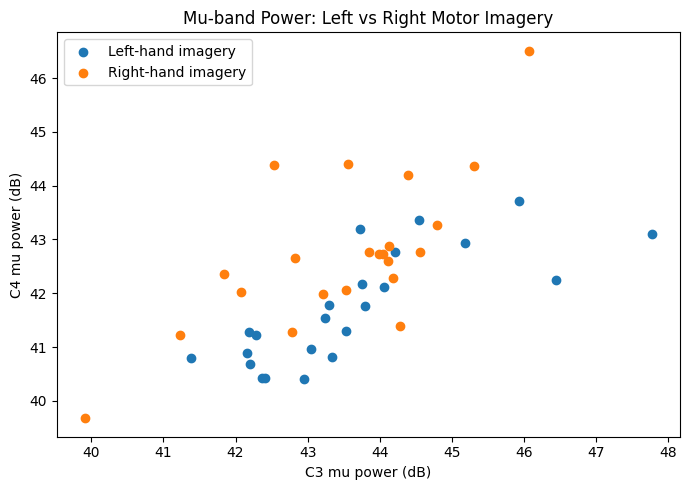

In [27]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    mu_power_db[combined_y_binary == 0, 0],
    mu_power_db[combined_y_binary == 0, 1],
    label="Left-hand imagery"
)

ax.scatter(
    mu_power_db[combined_y_binary == 1, 0],
    mu_power_db[combined_y_binary == 1, 1],
    label="Right-hand imagery"
)

ax.set_xlabel("C3 mu power (dB)")
ax.set_ylabel("C4 mu power (dB)")
ax.set_title("Mu-band Power: Left vs Right Motor Imagery")
ax.legend()

fig.tight_layout()

fig.savefig(
    "../figures/mu_power_scatter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The two classes overlap substantially, but the distribution suggests that relative mu-band activity across C3 and C4 contains useful information for distinguishing left- and right-hand imagery.

In [28]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

mu_difference = (
    mu_power_db[:, 1] - mu_power_db[:, 0]
).reshape(-1, 1)

mu_beta_features = np.column_stack(
    (mu_power_db, beta_power_db)
)

mu_scores = cross_val_score(
    LogisticRegression(),
    mu_power_db,
    combined_y_binary,
    cv=cv,
    scoring="accuracy"
)

mu_diff_scores = cross_val_score(
    LogisticRegression(),
    mu_difference,
    combined_y_binary,
    cv=cv,
    scoring="accuracy"
)

beta_scores = cross_val_score(
    LogisticRegression(),
    beta_power_db,
    combined_y_binary,
    cv=cv,
    scoring="accuracy"
)

mu_beta_scores = cross_val_score(
    LogisticRegression(),
    mu_beta_features,
    combined_y_binary,
    cv=cv,
    scoring="accuracy"
)

print(f"C3/C4 mu power:        {mu_scores.mean():.3f}")
print(f"C4 - C3 mu difference: {mu_diff_scores.mean():.3f}")
print(f"C3/C4 beta power:       {beta_scores.mean():.3f}")
print(f"Mu + beta power:         {mu_beta_scores.mean():.3f}")

C3/C4 mu power:        0.733
C4 - C3 mu difference: 0.711
C3/C4 beta power:       0.467
Mu + beta power:         0.667


## 4. Common Spatial Patterns (CSP)

The handcrafted features above use only C3 and C4. Common Spatial Patterns (CSP) instead learns spatial combinations of all 64 EEG channels that maximize variance differences between left- and right-hand motor imagery.

The continuous EEG is first band-pass filtered from 8–30 Hz, covering the mu and beta ranges, before extracting the 4-second epochs used for CSP.

In [29]:
filtered_raw = combined_raw.copy().filter(
    l_freq=8,
    h_freq=30
)

csp_epochs = mne.Epochs(
    filtered_raw,
    combined_events,
    event_id=combined_motor_event_id,
    tmin=0,
    tmax=4.0,
    baseline=None,
    preload=True
)

X_csp = csp_epochs.get_data()

print(X_csp.shape)

(45, 64, 641)


In [30]:
csp = CSP(
    n_components=4,
    reg="ledoit_wolf",
    log=True,
    norm_trace=False
)

csp_model = make_pipeline(
    csp,
    LogisticRegression(max_iter=1000)
)

csp_scores = cross_val_score(
    csp_model,
    X_csp,
    combined_y_binary,
    cv=cv,
    scoring="accuracy"
)

print("CSP fold accuracies:", csp_scores)
print("CSP mean accuracy:", csp_scores.mean())

CSP fold accuracies: [0.88888889 0.66666667 1.         0.77777778 0.55555556]
CSP mean accuracy: 0.7777777777777777


In [31]:
csp_y_pred = cross_val_predict(
    csp_model,
    X_csp,
    combined_y_binary,
    cv=cv
)

csp_cm = confusion_matrix(
    combined_y_binary,
    csp_y_pred
)

print(csp_cm)

[[19  4]
 [ 6 16]]


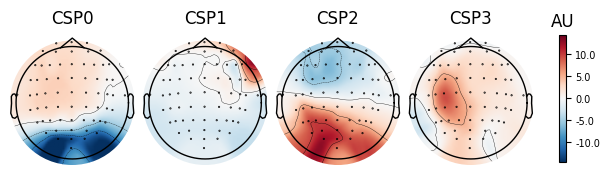

In [32]:
csp_visual = CSP(
    n_components=4,
    reg="ledoit_wolf",
    log=True,
    norm_trace=False
)

csp_visual.fit(X_csp, combined_y_binary)

fig = csp_visual.plot_patterns(
    csp_epochs.info,
    components=[0, 1, 2, 3],
    ch_type="eeg"
)


In [33]:
print(
    classification_report(
        combined_y_binary,
        csp_y_pred,
        target_names=["Left", "Right"]
    )
)

              precision    recall  f1-score   support

        Left       0.76      0.83      0.79        23
       Right       0.80      0.73      0.76        22

    accuracy                           0.78        45
   macro avg       0.78      0.78      0.78        45
weighted avg       0.78      0.78      0.78        45



## 5. Results

The models are compared using the mean accuracy across the same stratified 5-fold cross-validation splits.

The strongest performance is obtained with CSP followed by logistic regression. The simple C3/C4 mu-power baseline also performs reasonably well, while beta-band power alone does not provide useful discrimination for this dataset.

In [34]:
results = pd.DataFrame({
    "Method": [
        "C3/C4 mu power",
        "C4 - C3 mu difference",
        "C3/C4 beta power",
        "Mu + beta power",
        "CSP + Logistic Regression"
    ],
    "Mean CV Accuracy": [
        mu_scores.mean(),
        mu_diff_scores.mean(),
        beta_scores.mean(),
        mu_beta_scores.mean(),
        csp_scores.mean()
    ]
})

results["Mean CV Accuracy (%)"] = (
    100 * results["Mean CV Accuracy"]
).round(1)

print(results[["Method", "Mean CV Accuracy (%)"]])

                      Method  Mean CV Accuracy (%)
0             C3/C4 mu power                  73.3
1      C4 - C3 mu difference                  71.1
2           C3/C4 beta power                  46.7
3            Mu + beta power                  66.7
4  CSP + Logistic Regression                  77.8


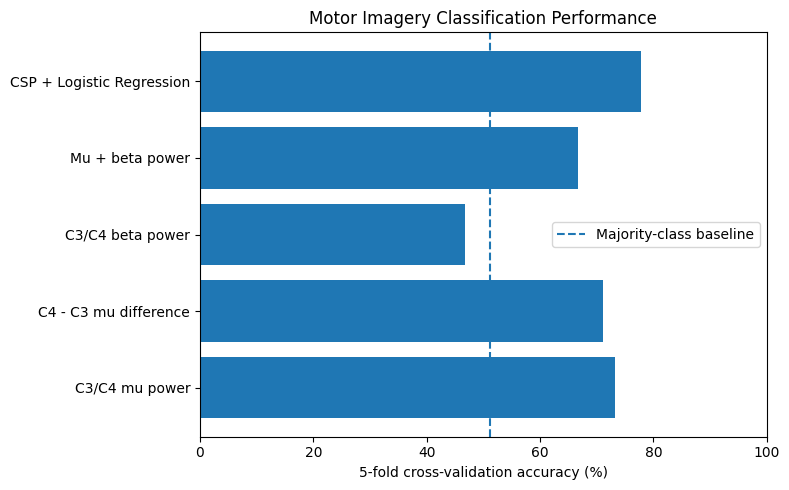

In [35]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    results["Method"],
    results["Mean CV Accuracy (%)"]
)

ax.axvline(
    23 / 45 * 100,
    linestyle="--",
    label="Majority-class baseline"
)

ax.set_xlabel("5-fold cross-validation accuracy (%)")
ax.set_title("Motor Imagery Classification Performance")
ax.set_xlim(0, 100)
ax.legend()

fig.tight_layout()

fig.savefig(
    "../figures/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

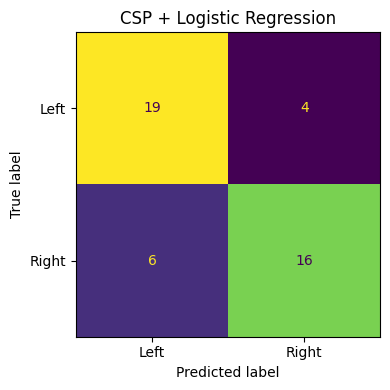

In [36]:
fig, ax = plt.subplots(figsize=(5, 4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=csp_cm,
    display_labels=["Left", "Right"]
)

disp.plot(
    ax=ax,
    values_format="d",
    colorbar=False
)

ax.set_title("CSP + Logistic Regression")

fig.tight_layout()

fig.savefig(
    "../figures/csp_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 6. Limitations and next steps

This analysis is an exploratory within-subject classification study based on one participant and 45 motor-imagery trials.

Important limitations include:

- the small number of trials;
- the use of only one participant;
- trial-level cross-validation, meaning trials from the same recording run may appear in both training and test folds;
- limited model and hyperparameter exploration.

Future work could evaluate generalization across recording runs and participants, explore additional preprocessing and feature-extraction methods, and compare the classical approaches with neural-network models.